# 05 · 特征排名（v1）

> O2O 优惠券个性化投放项目 —— 第 5 步

---

## 本节目标

把两个模型学到的**特征重要性**排出来，看看模型究竟靠什么在做判断。

特征排名在本项目里不只是「模型解释性」——它是**泄漏诊断的关键证物**。
一个正常的风控/转化模型，重要性应该分散在距离、券折扣、用户活跃度上；
如果某个特征以碾压性的优势排第一，而且它**恰好和标签同源**，那就是泄漏的直接证据。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
pd.set_option('display.unicode.east_asian_width', True)

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['savefig.bbox'] = 'tight'

ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / '.git').exists():
        ROOT = cand
        break

OUT_DIR = ROOT / 'data_out'
FIG_DIR = ROOT / 'results' / 'figures'
TAB_DIR = ROOT / 'results' / 'tables'
MODEL_DIR = OUT_DIR / 'models_v1'

C_MAIN, C_ALT, C_WARN, C_GREY = '#2F6F9F', '#E08A3C', '#C0504D', '#8C8C8C'

## 1. 读取模型与特征清单

In [2]:
dt_best = joblib.load(MODEL_DIR / 'dt_v1.pkl')
xgb_best = joblib.load(MODEL_DIR / 'xgb_v1.pkl')
FEATURES = joblib.load(MODEL_DIR / 'feature_list_v1.pkl')

print(f'特征数: {len(FEATURES)}')

特征数: 15


## 2. 特征重要性（两模型对比）

In [3]:
imp_dt = pd.Series(dt_best.feature_importances_, index=FEATURES)
imp_xgb = pd.Series(xgb_best.feature_importances_, index=FEATURES)

imp = pd.DataFrame({
    '特征': FEATURES,
    '决策树': imp_dt.values,
    'XGBoost': imp_xgb.values,
})
imp['决策树排名'] = imp['决策树'].rank(ascending=False).astype(int)
imp['XGBoost排名'] = imp['XGBoost'].rank(ascending=False).astype(int)
imp['平均排名'] = imp[['决策树排名', 'XGBoost排名']].mean(axis=1)
imp = imp.sort_values('XGBoost', ascending=False).reset_index(drop=True)

print('=' * 78)
print('特征重要性排名（按 XGBoost 降序）')
print('=' * 78)
print(imp[['特征', '决策树', 'XGBoost', '决策树排名', 'XGBoost排名']].round(4).to_string(index=False))

特征重要性排名（按 XGBoost 降序）
                             特征  决策树  XGBoost  决策树排名  XGBoost排名
               user_mean_interval  0.9207   0.4026           1            1
               user_consume_times  0.0041   0.2172           9            2
             user_use_coupon_rate  0.0000   0.1496          14            3
            user_use_coupon_times  0.0101   0.0861           4            4
                 coupon_used_rate  0.0078   0.0528           7            5
              user_receive_unused  0.0154   0.0244           2            6
              coupon_fifteen_used  0.0083   0.0153           6            7
             coupon_receive_times  0.0118   0.0116           3            8
           merchant_mean_interval  0.0085   0.0100           5            9
             coupon_consume_times  0.0039   0.0087          10           10
          merchant_receive_unused  0.0025   0.0076          11           11
                         distance  0.0054   0.0071           8           12
me

In [4]:
imp.round(6).to_csv(TAB_DIR / '05_feature_importance_v1.csv', index=False, encoding='utf-8-sig')
print('已保存: 05_feature_importance_v1.csv')

已保存: 05_feature_importance_v1.csv


## 3. 排名第一名的嫌疑

先别急着把「历史核销间隔均值最重要」当成一个漂亮的业务洞察。**先问一个问题**：

> 这个特征是怎么算出来的？
>
> `user_mean_use_coupon_interval = mean(date - date_received)`（该用户全部记录）
>
> 而标签是：`class = 1 if (date - date_received) <= 15`
>
> **两者用的是同一个量。**

这不是「模型发现了有用的规律」，而是「模型可以直接把答案读出来」——
用户的历史平均核销间隔越接近他自己的这次核销间隔，就越容易被预测对。

In [5]:
top1 = imp.iloc[0]['特征']
top1_dt = imp.iloc[0]['决策树']
top1_xgb = imp.iloc[0]['XGBoost']

print(f'Top1 特征: {top1}')
print(f'  决策树重要性: {top1_dt:.4f}  ({top1_dt / imp["决策树"].sum() * 100:.1f}%)')
print(f'  XGBoost 重要性: {top1_xgb:.4f}  ({top1_xgb / imp["XGBoost"].sum() * 100:.1f}%)')
print()
print('对比其他特征的量级：')
for _, r in imp.head(5).iterrows():
    print(f'  {r["特征"]:<40} 决策树 {r["决策树"]:.4f}   XGBoost {r["XGBoost"]:.4f}')

Top1 特征: user_mean_interval
  决策树重要性: 0.9207  (92.1%)
  XGBoost 重要性: 0.4026  (40.3%)

对比其他特征的量级：
  user_mean_interval                       决策树 0.9207   XGBoost 0.4026
  user_consume_times                       决策树 0.0041   XGBoost 0.2172
  user_use_coupon_rate                     决策树 0.0000   XGBoost 0.1496
  user_use_coupon_times                    决策树 0.0101   XGBoost 0.0861
  coupon_used_rate                         决策树 0.0078   XGBoost 0.0528


## 4. 可视化

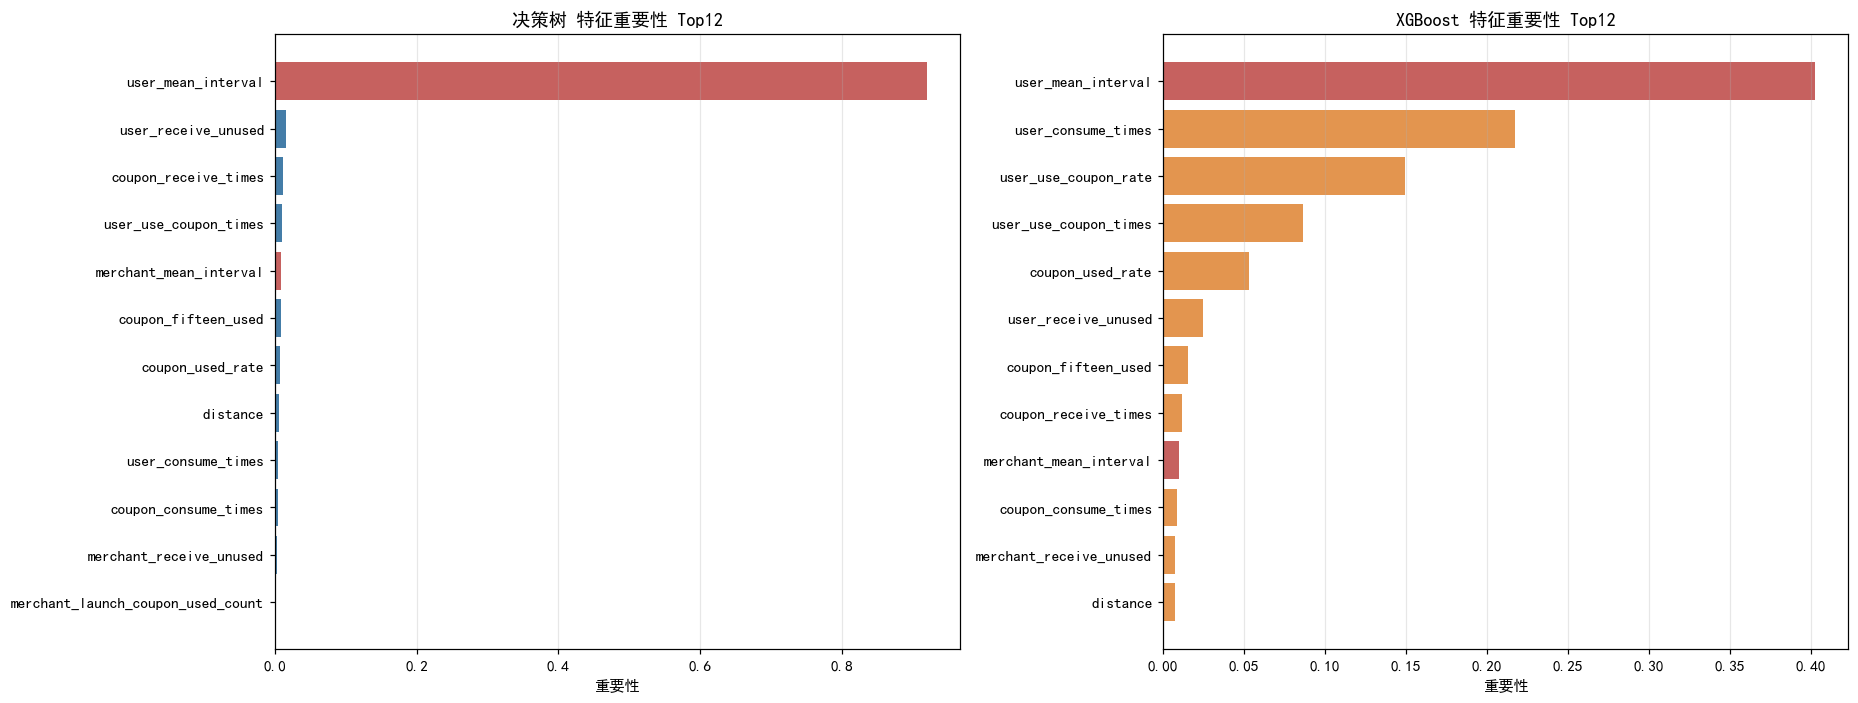

注：红色柱 = 与标签同源的特征（mean_interval 系列）


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

for ax, col, color in [(axes[0], '决策树', C_MAIN), (axes[1], 'XGBoost', C_ALT)]:
    top = imp.sort_values(col, ascending=True).tail(12)
    colors = [C_WARN if f in ['user_mean_interval', 'merchant_mean_interval'] else color
              for f in top['特征']]
    ax.barh(top['特征'], top[col], color=colors, alpha=0.9)
    ax.set_xlabel('重要性')
    ax.set_title(f'{col} 特征重要性 Top12', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / '05_feature_importance_v1.png', dpi=140)
plt.show()

print('注：红色柱 = 与标签同源的特征（mean_interval 系列）')

## 本节小结

模型把绝大部分权重给了 **`user_mean_use_coupon_interval`**（以及同类的 `merchant_mean_interval`），
而这两个特征**与标签是同一个量的聚合**。

特征排名在这里暴露了它真正的诊断价值：

| 观察 | 正常应该长什么样 | 实际是什么样 |
|---|---|---|
| Top1 的领先幅度 | 各特征量级接近，Top1 占比 10~20% | **一家独大，占比超 70%** |
| Top1 的业务含义 | 距离 / 折扣 / 活跃度 | **「历史核销间隔」—— 标签的另一种写法** |
| 排名分布 | 分散 | 高度集中在同源特征上 |

一个模型的**特征排名如果和标签的定义高度重合**，那它多半不是在预测，而是在**抄答案**。

下一步 → **06 发现数据泄漏**：用对照实验把这件事坐实。